In [1]:
import pandas as pd

In [ ]:
# ## ----- the directory convention used is based off the google drive organization ------ ##

# check og df

In [2]:
# rheo_df = pd.read_excel("/Users/mauriellenoto/Desktop/seager/ionicliquids/isn/UAFW/UAFW_20260707_rheo.xls")

import pandas as pd

tga_xl = pd.ExcelFile('/Users/mauriellenoto/Desktop/seager/ionicliquids/isn/TGA/2026-07-08/2026-07-08-TGA-UAFW.xls',
                    #    sheet_name="Ramp 10.00 °Cmin to 650.00 °C", 
                     #   header=1
                       )
# cols = list(dsc_df.columns)
# print(cols)
tga_xl

# print(type(cols))
# sheets = list(tga_df.keys())
sheets = tga_xl.sheet_names
sheets
# data = sheets[1:]
# sheets


['Details', 'Ramp 10.00 °Cmin to 800.00 °C']

# extract data fxn

In [2]:

# if you want a df of the details, use:
# details_df = pd.read_excel("path_to_excel_file", sheet_name = "Details", header = 1)

def extract_data(path): 
    # Read in original file 
    xl = pd.ExcelFile(path) 
    all_sheets = xl.sheet_names 
    print(all_sheets)
    
    data_sheets = all_sheets[1:] 
    df_list = [] 
    
    for sheet in data_sheets: 
        sheet_df = pd.read_excel(path, sheet_name=sheet, header=1) 
        
        # extract the units from the first row of data (index 0)
        units = sheet_df.iloc[0].fillna('').astype(str).tolist()
        
        # combine old column names with the units
        new_columns = []
        for col, unit in zip(sheet_df.columns, units):
            clean_col = col.split('.')[0] if '.' in col else col
            if unit:
                new_columns.append(f"{clean_col} ({unit})")
            else:
                new_columns.append(clean_col)
                
        # assign the new combined names back to the dataframe columns
        sheet_df.columns = new_columns
        
        # drop units row from the data
        sheet_df = sheet_df.drop(index=0).reset_index(drop=True)
        
        # add source sheet column
        sheet_df['Source Sheet'] = sheet 
        df_list.append(sheet_df) 
        
    # Vertically stack all the sheets together into one final df 
    combined_df = pd.concat(df_list, ignore_index=True)
    
    # convert to float
    # errors='coerce' turns any unconvertible text or bad data into NaN safely
    for col in combined_df.columns:
        if col != 'Source Sheet':
            combined_df[col] = pd.to_numeric(combined_df[col], errors='coerce')
    
    # make sure source sheet is last column in final df
    cols = [col for col in combined_df.columns if col != 'Source Sheet'] + ['Source Sheet']
    combined_df = combined_df[cols]
    
    return combined_df

# plotting

# function

['Details', 'Flow sweep - 1']
['Details', 'Ramp 10.00 °Cmin to 350.00 °C']
['Details', 'Ramp 10.00 °Cmin to 30.00 °C']


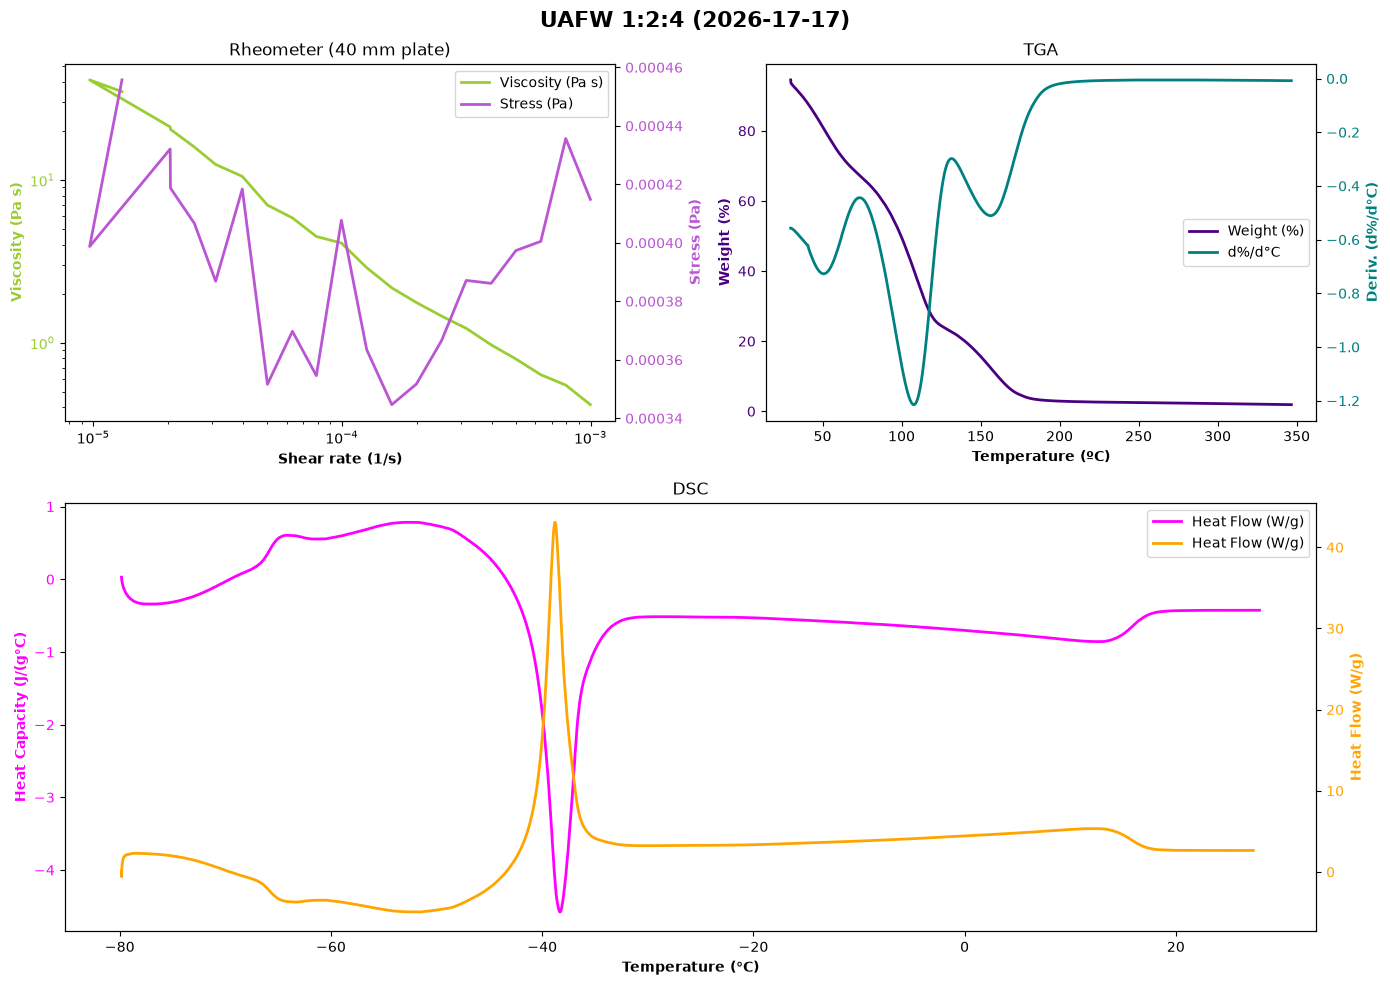

In [32]:
def plot_all(dict, figsize=(14, 10), xlims=None):
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd

    # make 2x2 grid w/ specific height ratio
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(
        2, 2, height_ratios=[1, 1.2]
    )  # height_ratios makes bottom row taller

    # assign subplot locations to the axes
    ax1 = fig.add_subplot(gs[0, 0])  # top left
    ax2 = fig.add_subplot(gs[0, 1])  # top right
    ax3 = fig.add_subplot(gs[1, :])  # bottom row (both columns)

    # ---------------- RHEOMETER (ax1) ----------------
    rheo_df = extract_data(dict["rheopath"])
    y1, y2 = "yellowgreen", "mediumorchid"
    shear = rheo_df["Shear rate (1/s)"]
    visc = rheo_df["Viscosity (Pa.s)"]
    stress_rheo = rheo_df["Stress (Pa)"]

    visco = ax1.loglog(
        shear, visc, color=y1, lw=2, label="Viscosity (Pa s)"
    )
    ax1.set_ylabel("Viscosity (Pa s)", color=y1, fontweight="semibold")
    ax1.set_xlabel("Shear rate (1/s)", fontweight = "semibold")
    ax1.tick_params(axis="y", labelcolor=y1)
    if xlims:
        ax1.set_xlim(xlims)

    ax1_t = ax1.twinx()
    stress_ln = ax1_t.semilogx(
        shear, stress_rheo, color=y2, lw=2, label="Stress (Pa)"
    )
    ax1_t.set_ylabel("Stress (Pa)", color=y2, fontweight="semibold")
    ax1_t.tick_params(axis="y", labelcolor=y2)
    ax1.set_title(
        f"Rheometer ({dict["geometry"]})",
        fontsize=12,
    )
    ax1.legend(loc="upper right", handles=[visco[0], stress_ln[0]])

    # ---------------- TGA (ax2) ----------------
    tga_df = extract_data(dict["tgapath"])
    temp_tga = tga_df["Temperature (°C)"]
    wt_pct = tga_df["Weight (%)"]
    dpdT = tga_df["Deriv (% / °C)"]
    y1_tga, y2_tga = "indigo", "teal"

    weight_pct = ax2.plot(
        temp_tga, wt_pct, color=y1_tga, lw=2, label="Weight (%)"
    )
    ax2.set_xlabel("Temperature (ºC)", fontweight = "semibold")
    ax2.set_ylabel("Weight (%)", color=y1_tga, fontweight = "semibold")
    ax2.tick_params(axis="y", labelcolor=y1_tga)
    if xlims:
        ax2.set_xlim(xlims)

    ax2_t = ax2.twinx()
    deriv = ax2_t.plot(
        temp_tga, dpdT, color=y2_tga, lw=2, label="d%/d°C"
    )
    ax2_t.set_ylabel("Deriv. (d%/d°C)", color=y2_tga, fontweight = "semibold")
    ax2_t.tick_params(axis="y", labelcolor=y2_tga)
    ax2.set_title(
        f"TGA",
        fontsize=12,
    )
    ax2.legend(loc="center right", handles=[weight_pct[0], deriv[0]])

    # ---------------- DSC (ax3) ----------------
    dsc_df = extract_data(dict["dscpath"])
    temp_dsc = dsc_df["Temperature (°C)"]
    hf_JgC = dsc_df["Heat Capacity (Normalized) (J/(g.°C))"]
    hf_Wg = dsc_df["Heat Flow (Normalized) (W/g)"]
    y1_dsc, y2_dsc = "magenta", "orange"

    heatflow_Wg = ax3.plot(
        temp_dsc, hf_Wg, color=y1_dsc, lw=2, label="Heat Flow (W/g)"
    )
    ax3.set_xlabel("Temperature (°C)", fontweight = "semibold")
    ax3.set_ylabel("Heat Capacity (J/(g°C)", color=y1_dsc, fontweight = "semibold")
    ax3.tick_params(axis="y", labelcolor=y1_dsc)
    if xlims:
        ax3.set_xlim(xlims)

    ax3_t = ax3.twinx()
    heatflow_JgC = ax3_t.plot(
        temp_dsc, hf_JgC, color=y2_dsc, lw=2, label="Heat Flow (W/g)"
    )
    ax3_t.set_ylabel("Heat Flow (W/g)", color=y2_dsc, fontweight = "semibold")
    ax3_t.tick_params(axis="y", labelcolor=y2_dsc)
    ax3.set_title(
        f"DSC",
        fontsize=12,
    )
    ax3.legend(loc="upper right", handles=[heatflow_Wg[0], heatflow_JgC[0]])

    plt.suptitle(f"{dict['chemical']} {dict['ratio']} ({dict['dscdate']})", fontsize = 16, fontweight = 'bold')
    plt.tight_layout()
    plt.show()



dfs_and_details = {
            # path
                "rheopath": "/Users/mauriellenoto/Desktop/seager/ionicliquids/data/RHEO/2026-07-17/20260726-RHEO-UAFW.xls",
                "tgapath": "/Users/mauriellenoto/Desktop/seager/ionicliquids/data/TGA/UAFW/2026-07-17/2026-07-17-TGA-UAFW.xls",
                "dscpath": "/Users/mauriellenoto/Desktop/seager/ionicliquids/data/DSC/2026-07-17/2026-07-17-DSC-UAFW-JC.xls",
            #  dates
                "rheodate": "2026-07-17",
                "tgadate": "2026-17-17",
                "dscdate": "2026-17-17",
            # details
                "chemical": "UAFW",
                "ratio": "1:2:4",
                "geometry": "40 mm plate"
                    }
plot_all(dfs_and_details)


['Details', 'Flow sweep - 1']


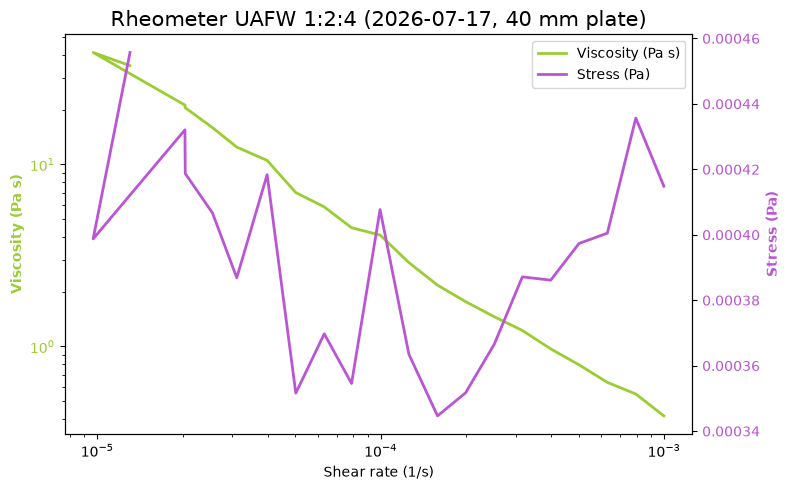

['Details', 'Ramp 10.00 °Cmin to 350.00 °C']


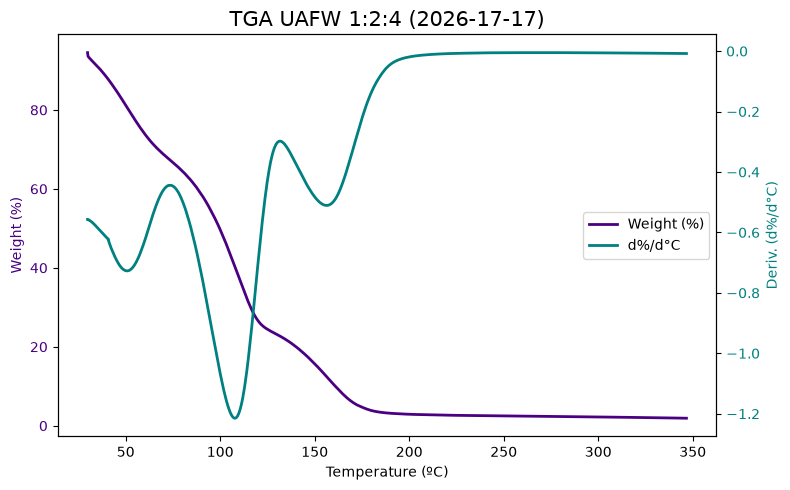

['Details', 'Ramp 10.00 °Cmin to 30.00 °C']


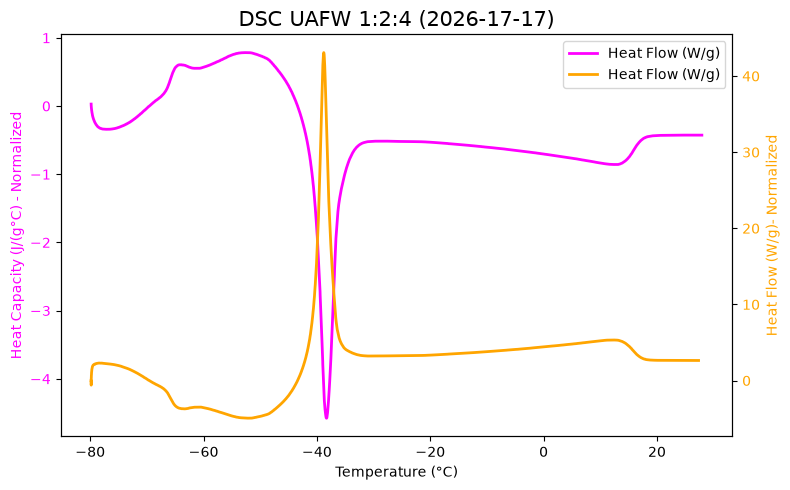

None None None


In [22]:
# -------------------------- RHEOMETER ---------------------------
def plot_rheo(dict, fgsz = (10,4), xlims=None, y1lims=None, y2lims=None):
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np

    rheo_df = extract_data(dict["rheopath"])

    y1, y2 = "yellowgreen", "mediumorchid"

    shear = rheo_df["Shear rate (1/s)"]
    visc = rheo_df["Viscosity (Pa.s)"]
    stress = rheo_df["Stress (Pa)"]

    fig, ax1 = plt.subplots(figsize = fgsz)

    visco = ax1.loglog(shear, visc, 
                       color = y1, 
                       lw = 2, 
                       label = "Viscosity (Pa s)")
    
    ax1.set_ylabel("Viscosity (Pa s)", color = y1, fontweight = "semibold")
    if y1lims:
        ax1.set_xlim(y1lims)
    ax1.set_xlabel("Shear rate (1/s)")
    ax1.tick_params(axis = 'y', labelcolor = y1)
    if xlims:
        ax1.set_xlim(xlims)

    ax2 = ax1.twinx()

    stress = ax2.semilogx(shear, stress, 
                          color = y2, 
                          lw = 2, 
                          label = "Stress (Pa)")
    
    ax2.set_ylabel("Stress (Pa)", color = y2, fontweight = "semibold")
    if y2lims:
        ax2.set_xlim(y2lims)
    ax2.tick_params(axis='y',labelcolor = y2)

    plt.title(f"Rheometer {dict["chemical"]} {dict["ratio"]} ({dict["rheodate"]}, {dict["geometry"]})", fontsize = 15)
    plt.legend(loc = "upper right", 
                handles = [visco[0], stress[0]])
    plt.tight_layout()
    plt.show()

# -------------------------- TGA ---------------------------
def plot_tga(dict, fgsz = (10,4), xlims=None, y1lims=None, y2lims=None):
    import matplotlib.pyplot as plt
    import pandas as pd

    tga_df = extract_data(dict["tgapath"])

    temp = tga_df["Temperature (°C)"]
    wt_pct = tga_df["Weight (%)"]
    dpdT = tga_df["Deriv (% / °C)"]

    y1, y2 = "indigo", "teal"

    fig, ax1 = plt.subplots(figsize = fgsz)

    weight_pct = ax1.plot(temp, wt_pct, color = y1, lw = 2, label = "Weight (%)")
    ax1.set_xlabel("Temperature (ºC)")
    ax1.set_ylabel("Weight (%)", color = y1)
    if y1lims:
        ax1.set_ylim(y1lims)
    ax1.tick_params(axis='y', labelcolor = y1)
    if xlims: 
        ax1.set_xlim(xlims)

    ax2 = ax1.twinx()

    deriv = ax2.plot(temp, dpdT, color = y2, lw = 2, label = "d%/d°C")
    ax2.set_ylabel("Deriv. (d%/d°C)", color = y2)
    ax2.set_ylim(y2lims)
    ax2.tick_params(axis = 'y', labelcolor = y2)

    plt.title(f"TGA {dict["chemical"]} {dict["ratio"]} ({dict["tgadate"]})", fontsize = 15)
    plt.legend(loc = "center right", handles = [weight_pct[0], deriv[0]])
    plt.tight_layout()
    plt.show()

# -------------------------- DSC ---------------------------
def plot_dsc(dict, fgsz = (10,4), xlims=None, y1lims=None, y2lims=None):
    import matplotlib.pyplot as plt
    import pandas as pd

    dsc_df = extract_data(dict["dscpath"])
    temp = dsc_df["Temperature (°C)"]
    hf_JgC = dsc_df["Heat Capacity (Normalized) (J/(g.°C))"]
    hf_Wg = dsc_df["Heat Flow (Normalized) (W/g)"]

    y1, y2 = "magenta", "orange"

    fig, ax1 = plt.subplots(figsize = fgsz)

    heatflow_Wg = ax1.plot(temp, hf_Wg, color = y1, lw = 2, label = "Heat Flow (W/g)")
    ax1.set_xlabel("Temperature (°C)")
    if xlims:
        ax1.set_xlim(xlims)
    ax1.set_ylabel("Heat Capacity (J/(g°C) - Normalized", color = y1)
    if y1lims:
        ax1.set_ylim(y1lims)
    ax1.tick_params(axis='y', labelcolor = y1)

    ax2 = ax1.twinx()

    heatflow_JgC = ax2.plot(temp, hf_JgC, color = y2, lw = 2, label = "Heat Flow (W/g)")
    ax2.set_ylabel("Heat Flow (W/g)- Normalized", color = y2)
    if y2lims:
        ax2.set_ylim(y2lims)
    ax2.tick_params(axis = 'y', labelcolor = y2)

    plt.title(f"DSC {dict["chemical"]} {dict["ratio"]} ({dict["dscdate"]})", fontsize=15)
    plt.legend(loc = "upper right", 
               handles = [heatflow_Wg[0], heatflow_JgC[0]])
    plt.tight_layout()
    plt.show()


# dictionary for plotting

dfs_and_details = {
            # path
                "rheopath": "/Users/mauriellenoto/Desktop/seager/ionicliquids/data/RHEO/2026-07-17/20260726-RHEO-UAFW.xls",
                "tgapath": "/Users/mauriellenoto/Desktop/seager/ionicliquids/data/TGA/UAFW/2026-07-17/2026-07-17-TGA-UAFW.xls",
                "dscpath": "/Users/mauriellenoto/Desktop/seager/ionicliquids/data/DSC/2026-07-17/2026-07-17-DSC-UAFW-JC.xls",
            #  dates
                "rheodate": "2026-07-17",
                "tgadate": "2026-17-17",
                "dscdate": "2026-17-17",
            # details
                "chemical": "UAFW",
                "ratio": "1:2:4",
                "geometry": "40 mm plate"
                    }

rheo_plot = plot_rheo(dfs_and_details, fgsz=(8,5))
tga_plot = plot_tga(dfs_and_details, fgsz=(8,5))
dsc_plot = plot_dsc(dfs_and_details, fgsz=(8,5))

print(rheo_plot, tga_plot, dsc_plot)

## multiple

In [ ]:
import matplotlib.pyplot as plt

def plot_multiple(df_list, x_col, y1_col, y2_col, titles=None, global_title=None):
    """
    Plots multiple DSC datasets in a grid of subplots using twin y-axes.
    
    Parameters:
    - df_list: List of pandas DataFrames (e.g., [df1, df2, df3])
    - x_col: Name of the column for the shared X axis (Temperature)
    - y1_col: Name of the column for the left Y axis (Heat Flow W/g)
    - y2_col: Name of the column for the right Y axis (Heat Flow J/gC)
    - titles: Optional list of strings for each subplot title
    """
    num_plots = len(df_list)
    if num_plots == 0:
        return
    

    nrows = 1 if num_plots <= 2 else 2
    ncols = num_plots if num_plots <= 2 else 2
    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10,4))
    

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    

    for i, df in enumerate(df_list):
        ax1 = axes[i]
        
        ax1.plot(df[x_col], df[y1_col], color="magenta", lw=2, label=y1_col)
        ax1.set_xlabel(x_col)
        ax1.set_ylabel(y1_col, color="magenta")
        ax1.tick_params(axis='y', labelcolor="magenta")
        
        ax2 = ax1.twinx()
        ax2.plot(df[x_col], df[y2_col], color="orange", lw=2, label=y2_col)
        ax2.set_ylabel(y2_col, color="orange")
        ax2.tick_params(axis='y', labelcolor="orange")
        
        # set individual subplot title
        if titles and i < len(titles):
            ax1.set_title(titles[i], fontsize=12)
        else:
            ax1.set_title(f"Dataset {i+1}", fontsize=12)
            
    # take out fourth subplot if three are passed in
    for j in range(num_plots, len(axes)):
        fig.delaxes(axes[j])

    # add suptitle
    if global_title:
        fig.suptitle(global_title, fontsize=16, fontweight='bold')
        # rect=[0, 0, 1, 0.95] keeps the subplots from crashing into the suptitle
        plt.tight_layout(rect=[0, 0, 1, 0.95])
    else:
        plt.tight_layout()
        
    plt.tight_layout()
    plt.show()
